In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import warnings
warnings.filterwarnings("ignore")

**Set up - Install Wandb**

In [3]:
!pip uninstall -y wandb
!pip install --no-cache-dir wandb==0.22.3

Found existing installation: wandb 0.25.1
Uninstalling wandb-0.25.1:
  Successfully uninstalled wandb-0.25.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 79.3 MB/s eta 0:00:00ta 0:00:01


In [4]:
import os
import gc
import random
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import wandb
print("wandb version:", wandb.__version__)

wandb version: 0.22.3


**WandB login**

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WANDB_TOKEN = user_secrets.get_secret("WANDB_TOKEN")

wandb.login(key=WANDB_TOKEN)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

**Config**

In [6]:
CONFIG = {
    "max_len": 128,
    "vocab_size": 25000,
    "embed_dim": 128,
    "num_filters": 100,
    "kernel_sizes": [2, 3, 4],
    "dropout": 0.3,
    "batch_size": 32,
    "epochs": 15,
    "lr": 1e-3,
    "seed": 42,
    "use_augmentation": True,
    "project": "DL-22f1000828-notebook-t22026",
    "entity": "22f1000828-t1-2026-indian-institute-of-technology-madras",
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

LABEL2IDX = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
IDX2LABEL = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}

In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(CONFIG['seed'])
print("Using Device:", CONFIG['device'])

Using Device: cuda


**Loading data**

In [8]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (2000, 8)
Test shape: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**EDA**

**Missing values and duplicates**

In [9]:
print("Train columns:", list(train.columns))
print("Test columns :", list(test.columns))

print()
print("Missing values in train:")
print(train.isnull().sum())

print()
print("Missing values in test:")
print(test.isnull().sum())

print()
print("Duplicate prompts in train:", train.duplicated(subset=['prompt']).sum())
print("Duplicate prompts in test :", test.duplicated(subset=['prompt']).sum())

Train columns: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']
Test columns : ['id', 'prompt', 'A', 'B', 'C', 'D', 'E']

Missing values in train:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Missing values in test:
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

Duplicate prompts in train: 242
Duplicate prompts in test : 8


**Answer distribution - is the data balanced**

answer
A    369
B    490
C    459
D    358
E    324
Name: count, dtype: int64


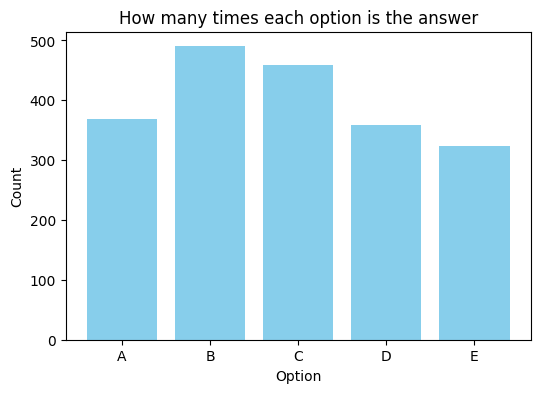


In percentage:
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

If I always guess the most common option: 24.5 %
If I guess randomly: 20.0 %


In [10]:
counts = train['answer'].value_counts().reindex(['A', 'B', 'C', 'D', 'E'], fill_value=0)
print(counts)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.title("How many times each option is the answer")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

print()
print("In percentage:")
print(train['answer'].value_counts(normalize=True) * 100)

print()
print("If I always guess the most common option:", round(counts.max() / len(train) * 100, 2), "%")
print("If I guess randomly: 20.0 %")

**Prompt length**

count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_len, dtype: float64


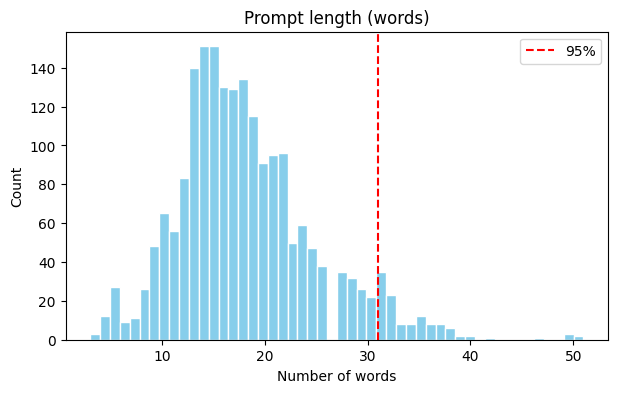

95% of the prompts have less than 31 words


In [11]:
train['prompt_len'] = train['prompt'].apply(lambda x: len(str(x).split()))

print(train['prompt_len'].describe())

plt.figure(figsize=(7, 4))
plt.hist(train['prompt_len'], bins=50, color='skyblue', edgecolor='white')
plt.axvline(train['prompt_len'].quantile(0.95), color='red', linestyle='--', label='95%')
plt.title("Prompt length (words)")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()
plt.show()

print("95% of the prompts have less than", int(train['prompt_len'].quantile(0.95)), "words")

**Are correct options longer than wrong options**

Average length of correct option: 28.66 words
Average length of wrong options : 25.68 words


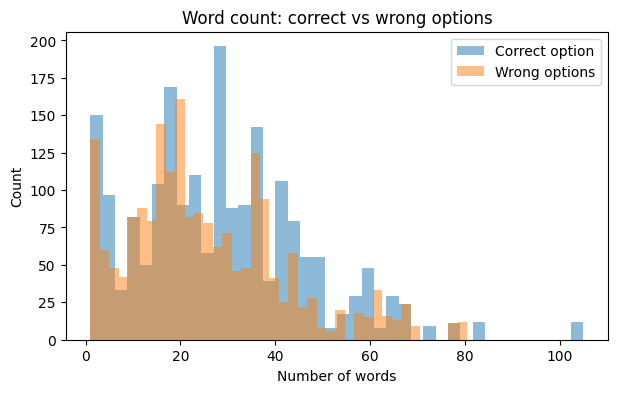


Accuracy if I always pick the longest option: 34.95 %


In [12]:
option_cols = ['A', 'B', 'C', 'D', 'E']

for col in option_cols:
    train['len_' + col] = train[col].apply(lambda x: len(str(x).split()))

correct_lens = []
wrong_lens = []

for i in range(len(train)):
    row = train.iloc[i]
    ans = row['answer']
    correct_lens.append(row['len_' + ans])
    wrong = [row['len_' + c] for c in option_cols if c != ans]
    wrong_lens.append(np.mean(wrong))

train['correct_len'] = correct_lens
train['avg_wrong_len'] = wrong_lens

print("Average length of correct option:", round(train['correct_len'].mean(), 2), "words")
print("Average length of wrong options :", round(train['avg_wrong_len'].mean(), 2), "words")

plt.figure(figsize=(7, 4))
plt.hist(train['correct_len'], bins=40, alpha=0.5, label='Correct option')
plt.hist(train['avg_wrong_len'], bins=40, alpha=0.5, label='Wrong options')
plt.title("Word count: correct vs wrong options")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.legend()
plt.show()

# what if I always pick the longest option?
longest = train[['len_' + c for c in option_cols]].idxmax(axis=1).str.replace('len_', '')
print()
print("Accuracy if I always pick the longest option:",
      round((longest == train['answer']).mean() * 100, 2), "%")

**Trick questions (words like NOT, EXCEPT)**

Questions with negation words: 0 ( 0.0 % )


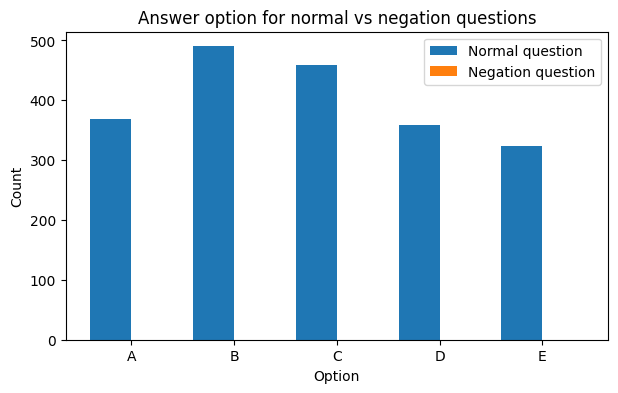

In [13]:
negation_words = ['NOT', 'EXCEPT', 'INCORRECT', 'FALSE', 'LEAST']
pattern = r'\b(' + '|'.join(negation_words) + r')\b'

train['has_negation'] = train['prompt'].apply(
    lambda x: bool(re.search(pattern, str(x), re.IGNORECASE))
)

n = train['has_negation'].sum()
print("Questions with negation words:", n, "(", round(n / len(train) * 100, 1), "% )")

# reindex so that all 5 letters are always present (even if the count is 0)
letters = ['A', 'B', 'C', 'D', 'E']
normal_q = train[train['has_negation'] == False]['answer'].value_counts().reindex(letters, fill_value=0)
trick_q = train[train['has_negation'] == True]['answer'].value_counts().reindex(letters, fill_value=0)

x = np.arange(5)
plt.figure(figsize=(7, 4))
plt.bar(x - 0.2, normal_q.values, width=0.4, label='Normal question')
plt.bar(x + 0.2, trick_q.values, width=0.4, label='Negation question')
plt.xticks(x, letters)
plt.title("Answer option for normal vs negation questions")
plt.xlabel("Option")
plt.ylabel("Count")
plt.legend()
plt.show()

**Word overlap between prompt and options**

In [14]:
def get_overlap(prompt, option):
    prompt_words = set(str(prompt).lower().split())
    option_words = set(str(option).lower().split())
    if len(option_words) == 0:
        return 0
    return len(prompt_words & option_words) / len(option_words)

for col in option_cols:
    train['overlap_' + col] = [get_overlap(p, o) for p, o in zip(train['prompt'], train[col])]

best_overlap = train[['overlap_' + c for c in option_cols]].idxmax(axis=1).str.replace('overlap_', '')
acc = (best_overlap == train['answer']).mean()

print("Accuracy of picking the option with most common words:", round(acc * 100, 2), "%")
print("(random guessing is 20 %)")

Accuracy of picking the option with most common words: 9.25 %
(random guessing is 20 %)


**Train vs test prompt length**

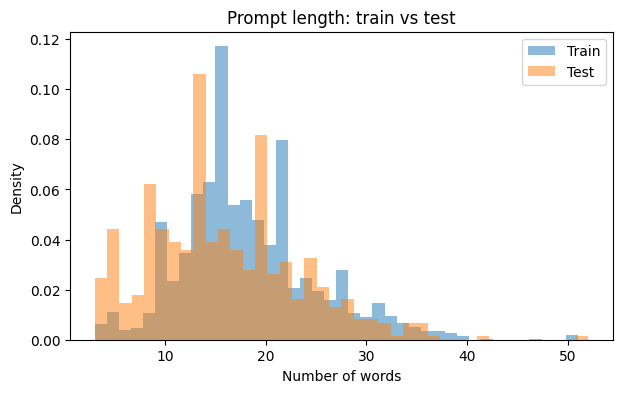

In [15]:
test['prompt_len'] = test['prompt'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(7, 4))
plt.hist(train['prompt_len'], bins=40, alpha=0.5, density=True, label='Train')
plt.hist(test['prompt_len'], bins=40, alpha=0.5, density=True, label='Test')
plt.title("Prompt length: train vs test")
plt.xlabel("Number of words")
plt.ylabel("Density")
plt.legend()
plt.show()

**How many words are there in total?**

Unique words in train: 2980
Unique words in test : 2975
Words in test not seen in train: 0 ( 0.0 % of test words )
Top 5000 words cover 100.0 % of the text
Top 10000 words cover 100.0 % of the text
Top 25000 words cover 100.0 % of the text
Top 50000 words cover 100.0 % of the text


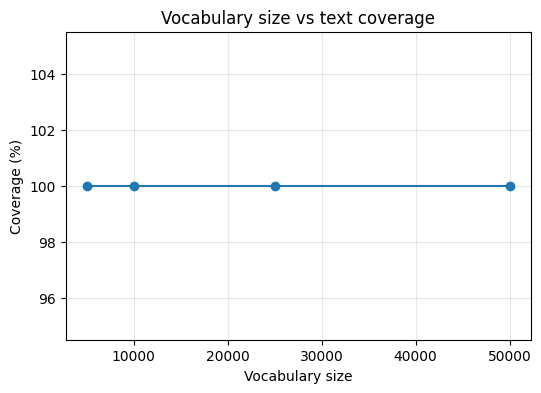

In [16]:
def count_words(df):
    c = Counter()
    for col in ['prompt'] + option_cols:
        for text in df[col]:
            c.update(re.findall(r'\w+', str(text).lower()))
    return c

train_words = count_words(train)
test_words = count_words(test)

print("Unique words in train:", len(train_words))
print("Unique words in test :", len(test_words))

new_words = set(test_words) - set(train_words)
new_count = sum(test_words[w] for w in new_words)
total_count = sum(test_words.values())
print("Words in test not seen in train:", len(new_words),
      "(", round(new_count / total_count * 100, 2), "% of test words )")

# how much of the text do the top N words cover
most_common = train_words.most_common()
total = sum(train_words.values())
sizes = [5000, 10000, 25000, 50000]
coverage = []
for n in sizes:
    cov = sum(c for w, c in most_common[:n]) / total * 100
    coverage.append(cov)
    print("Top", n, "words cover", round(cov, 2), "% of the text")

plt.figure(figsize=(6, 4))
plt.plot(sizes, coverage, marker='o')
plt.title("Vocabulary size vs text coverage")
plt.xlabel("Vocabulary size")
plt.ylabel("Coverage (%)")
plt.grid(True, alpha=0.3)
plt.show()

**Preprocessing**

In [17]:
# 1. fill missing values
for df in [train, test]:
    for col in ['prompt'] + option_cols:
        df[col] = df[col].fillna("")

# 2. clean the text
def clean_text(text):
    text = str(text).lower()
    text = text.replace("\u2019", "'").replace("\u201c", '"').replace("\u201d", '"')
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # remove links
    text = re.sub(r'\s+', ' ', text)                # remove extra spaces
    return text.strip()

for df in [train, test]:
    for col in ['prompt'] + option_cols:
        df[col] = df[col].apply(clean_text)

print("Example after cleaning:")
print(train.loc[0, 'prompt'][:300])

Example after cleaning:
pick the best possible answer: what is martin heidegger's view on the relationship between time and human existence? among the listed options.


**My own tokenizer**

In [18]:
class SimpleTokenizer:
    def __init__(self, vocab_size=25000):
        self.vocab_size = vocab_size
        self.word2idx = {'<pad>': 0, '<unk>': 1}

    def tokenize(self, text):
        return re.findall(r'\w+', str(text).lower())

    def build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(self.tokenize(text))

        # keep only the most common words
        for i, (word, count) in enumerate(counter.most_common(self.vocab_size - 2)):
            self.word2idx[word] = i + 2

    def encode(self, text, max_len):
        tokens = self.tokenize(text)
        ids = []
        for tok in tokens[:max_len]:
            ids.append(self.word2idx.get(tok, 1))   # 1 = unknown word
        while len(ids) < max_len:
            ids.append(0)                           # 0 = padding
        return ids

**Dataset class**

In [19]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_train=True, augment=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train
        self.augment = augment
        self.options = ['A', 'B', 'C', 'D', 'E']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])

        # make 5 texts: question + option
        texts = []
        for opt in self.options:
            texts.append(prompt + " [SEP] " + str(row[opt]))

        if self.is_train:
            label = LABEL2IDX[row['answer']]
        else:
            label = -1

        # augmentation: shuffle the order of the options
        if self.augment and self.is_train:
            order = [0, 1, 2, 3, 4]
            random.shuffle(order)
            texts = [texts[i] for i in order]
            label = order.index(label)   # the label moves with its option

        token_ids = []
        for t in texts:
            token_ids.append(self.tokenizer.encode(t, self.max_len))

        input_ids = torch.tensor(token_ids, dtype=torch.long)   # (5, max_len)
        mask = (input_ids != 0).long()                          # 1 = real word, 0 = padding

        item = {'input_ids': input_ids, 'mask': mask}
        if label >= 0:
            item['labels'] = torch.tensor(label, dtype=torch.long)
        return item

**Data Augmentation**

**Build the vocabulary and split train/validation**

In [20]:
print("Building vocabulary...")
tokenizer = SimpleTokenizer(vocab_size=CONFIG['vocab_size'])

all_texts = []
for col in ['prompt'] + option_cols:
    all_texts = all_texts + train[col].tolist()

tokenizer.build_vocab(all_texts)
print("Vocab size:", len(tokenizer.word2idx))

train_df, val_df = train_test_split(
    train,
    test_size=0.15,
    random_state=CONFIG['seed'],
    stratify=train['answer']
)
print("Train rows:", len(train_df), " Val rows:", len(val_df))

train_dataset = MCQDataset(train_df, tokenizer, CONFIG['max_len'],
                           is_train=True, augment=CONFIG['use_augmentation'])
val_dataset = MCQDataset(val_df, tokenizer, CONFIG['max_len'],
                         is_train=True, augment=False)

# check one sample
sample = train_dataset[0]
print("input_ids shape:", sample['input_ids'].shape)
print("label:", sample['labels'].item())

Building vocabulary...
Vocab size: 2982
Train rows: 1700  Val rows: 300
input_ids shape: torch.Size([5, 128])
label: 1


**Model - TextCNN**

In [21]:
class MCQTextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters=100,
                 kernel_sizes=[2, 3, 4], dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # one Conv1d for every kernel size, they all run in parallel
        self.convs = nn.ModuleList()
        for k in kernel_sizes:
            self.convs.append(nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k-1))

        out_dim = num_filters * len(kernel_sizes)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, 1)     # same scorer for all 5 options

    def forward(self, x, mask):
        batch_size = x.shape[0]
        num_options = x.shape[1]
        seq_len = x.shape[2]

        # treat the 5 options as 5 normal sentences in the batch
        x = x.view(-1, seq_len)                  # (batch*5, seq_len)
        mask = mask.view(-1, seq_len).float()

        embeds = self.embedding(x)               # (batch*5, seq_len, embed_dim)

        # Conv1d wants (batch, channels, length), so I swap the last two dimensions
        embeds = embeds.transpose(1, 2)          # (batch*5, embed_dim, seq_len)

        pooled_list = []
        for conv in self.convs:
            out = conv(embeds)                   # (batch*5, num_filters, new_len)
            out = F.relu(out)

            # hide the padding positions so max pooling can never pick them
            m = mask[:, :out.shape[2]]
            if m.shape[1] < out.shape[2]:
                pad_extra = out.shape[2] - m.shape[1]
                m = F.pad(m, (0, pad_extra), value=0)
            out = out.masked_fill(m.unsqueeze(1) == 0, -1e4)

            out = out.max(dim=2)[0]              # max over time -> (batch*5, num_filters)
            pooled_list.append(out)

        pooled = torch.cat(pooled_list, dim=1)   # (batch*5, num_filters * 3)

        pooled = self.dropout(pooled)
        logits = self.fc(pooled)                 # (batch*5, 1)
        logits = logits.view(batch_size, num_options)   # (batch, 5)
        return logits

**Quick check that the shapes are correct**

In [22]:
test_model = MCQTextCNN(len(tokenizer.word2idx), 64, 32, [2, 3, 4], 0.3)
test_batch = next(iter(DataLoader(train_dataset, batch_size=4)))

with torch.no_grad():
    out = test_model(test_batch['input_ids'], test_batch['mask'])

print("logits shape:", out.shape, "-> should be [4, 5]")
print("number of parameters:", sum(p.numel() for p in test_model.parameters()))

del test_model, test_batch
gc.collect()

logits shape: torch.Size([4, 5]) -> should be [4, 5]
number of parameters: 209473


27195

**MAP@3 function**

In [23]:
def map_at_3(probs, targets):
    # probs is (n, 5), targets is (n,)
    top3 = np.argsort(-probs, axis=1)[:, :3]
    score = 0.0
    for i in range(len(targets)):
        for rank in range(3):
            if top3[i][rank] == targets[i]:
                score = score + 1.0 / (rank + 1)
                break
    return score / len(targets)

**Training function**

In [24]:
def run_experiment(run_config, run_name):
    set_seed(run_config['seed'])
    device = run_config['device']

    train_loader = DataLoader(train_dataset, batch_size=run_config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=run_config['batch_size'], shuffle=False)

    model = MCQTextCNN(
        vocab_size=len(tokenizer.word2idx),
        embed_dim=run_config['embed_dim'],
        num_filters=run_config['num_filters'],
        kernel_sizes=run_config['kernel_sizes'],
        dropout=run_config['dropout']
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=run_config['lr'], weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    wandb.init(
        project=run_config['project'],
        name=run_name,
        config={k: str(v) for k, v in run_config.items()},
        reinit=True,
        settings=wandb.Settings(save_code=False)
    )

    model_path = "/kaggle/working/" + run_name + ".pth"
    best_map3 = 0.0
    best_acc = 0.0
    best_f1 = 0.0
    history = []

    print()
    print("=== Starting run:", run_name, "===")

    for epoch in range(run_config['epochs']):

        # ---------- training ----------
        model.train()
        train_loss = 0
        train_preds = []
        train_targets = []

        for batch in tqdm(train_loader, desc="Epoch " + str(epoch+1) + " [train]"):
            input_ids = batch['input_ids'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids, mask)
            loss = criterion(logits, labels)
            loss.backward()

            # LSTM gradients can explode, so I clip them
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss = train_loss + loss.item()
            train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_targets.extend(labels.cpu().numpy())

        train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average='macro')

        # ---------- validation ----------
        model.eval()
        val_loss = 0
        val_preds = []
        val_targets = []
        val_probs = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Epoch " + str(epoch+1) + " [val]"):
                input_ids = batch['input_ids'].to(device)
                mask = batch['mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids, mask)
                loss = criterion(logits, labels)

                val_loss = val_loss + loss.item()
                probs = F.softmax(logits, dim=1).cpu().numpy()
                val_probs.append(probs)
                val_preds.extend(probs.argmax(axis=1))
                val_targets.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='macro')
        val_map3 = map_at_3(np.vstack(val_probs), np.array(val_targets))

        print("Epoch", epoch+1,
              "| train loss:", round(train_loss, 4), "train acc:", round(train_acc, 4),
              "| val loss:", round(val_loss, 4), "val acc:", round(val_acc, 4),
              "val map3:", round(val_map3, 4))

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "val_map3": val_map3
        })

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
            "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1, "val_map3": val_map3
        })

        # save the model only if it improved
        if val_map3 > best_map3:
            best_map3 = val_map3
            best_acc = val_acc
            best_f1 = val_f1
            torch.save(model.state_dict(), model_path)
            print("   saved best model (val map3 =", round(val_map3, 4), ")")

    if not os.path.exists(model_path):
        torch.save(model.state_dict(), model_path)

    wandb.summary["best_val_acc"] = best_acc
    wandb.summary["best_val_f1"] = best_f1
    wandb.summary["best_val_map3"] = best_map3
    wandb.finish()

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "run_name": run_name,
        "config": run_config,
        "model_path": model_path,
        "best_val_acc": best_acc,
        "best_val_f1": best_f1,
        "best_val_map3": best_map3,
        "history": history
    }

**Run 3 experiments (tracked in WandB)**

In [25]:
experiment_configs = [
    # 1. baseline
    {**CONFIG, "embed_dim": 128, "num_filters": 100, "kernel_sizes": [2, 3, 4], "dropout": 0.3, "lr": 1e-3},
    # 2. bigger model, more dropout
    {**CONFIG, "embed_dim": 200, "num_filters": 150, "kernel_sizes": [2, 3, 4], "dropout": 0.4, "lr": 5e-4},
    # 3. longer phrases (kernels 3, 4, 5) to see if longer patterns help
    {**CONFIG, "embed_dim": 128, "num_filters": 100, "kernel_sizes": [3, 4, 5], "dropout": 0.3, "lr": 1e-3},
]

run_results = []
for i in range(len(experiment_configs)):
    run_name = "textcnn-run" + str(i + 1)
    result = run_experiment(experiment_configs[i], run_name)
    run_results.append(result)

print("All", len(run_results), "runs are done.")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



=== Starting run: textcnn-run1 ===


Epoch 1 [val]: 100%|██████████| 10/10 [00:00<00:00, 78.21it/s]


Epoch 1 | train loss: 1.2991 train acc: 0.4659 | val loss: 0.8365 val acc: 0.96 val map3: 0.9789
   saved best model (val map3 = 0.9789 )


Epoch 2 [val]: 100%|██████████| 10/10 [00:00<00:00, 77.02it/s]


...

Epoch 14 | train loss: 0.0065 train acc: 1.0 | val loss: 0.0005 val acc: 1.0 val map3: 1.0


Epoch 15 [val]: 100%|██████████| 10/10 [00:00<00:00, 72.81it/s]

Epoch 15 | train loss: 0.0058 train acc: 0.9988 | val loss: 0.0004 val acc: 1.0 val map3: 1.0


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_acc,▁▆▇▇███████████
train_f1,▁▆▇▇███████████
train_loss,█▄▃▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▇█████████████
val_f1,▁▇█████████████
val_loss,█▄▂▂▁▁▁▁▁▁▁▁▁▁▁
val_map3,▁▇█████████████
best_val_acc,1
best_val_f1,1
best_val_map3,1


All 3 runs are done.


**Compare the 3 runs**

       run_name  embed_dim  num_filters    kernels  dropout      lr  val_acc  \
0  textcnn-run1        128          100  [2, 3, 4]      0.3  0.0010      1.0   
1  textcnn-run2        200          150  [2, 3, 4]      0.4  0.0005      1.0   
2  textcnn-run3        128          100  [3, 4, 5]      0.3  0.0010      1.0   

   val_f1  val_map3  
0     1.0       1.0  
1     1.0       1.0  
2     1.0       1.0  


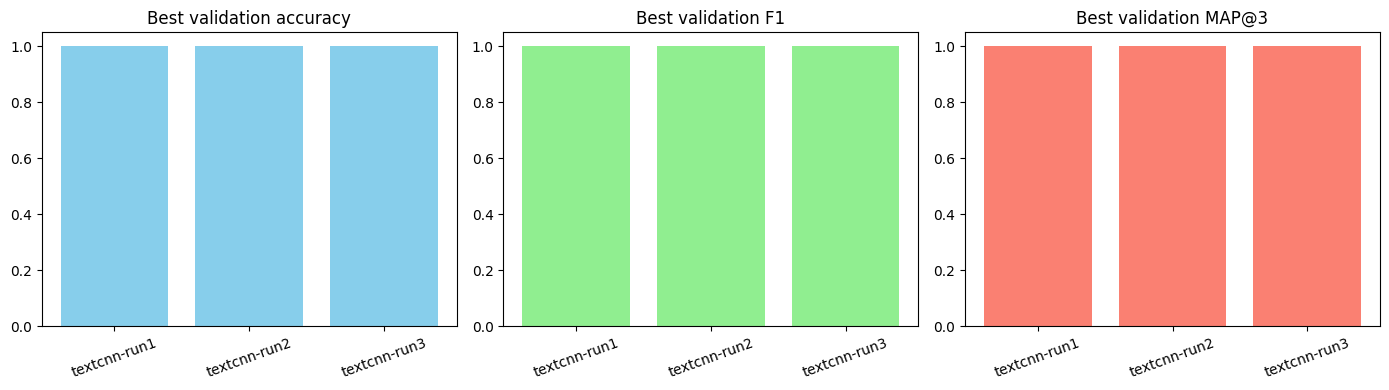


Best run: textcnn-run1 with val map3 = 1.0


In [26]:
rows = []
for r in run_results:
    rows.append({
        "run_name": r["run_name"],
        "embed_dim": r["config"]["embed_dim"],
        "num_filters": r["config"]["num_filters"],
        "kernels": str(r["config"]["kernel_sizes"]),
        "dropout": r["config"]["dropout"],
        "lr": r["config"]["lr"],
        "val_acc": r["best_val_acc"],
        "val_f1": r["best_val_f1"],
        "val_map3": r["best_val_map3"],
    })

comparison_df = pd.DataFrame(rows).sort_values("val_map3", ascending=False)
print(comparison_df)

names = comparison_df["run_name"]

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.bar(names, comparison_df["val_acc"], color='skyblue')
plt.title("Best validation accuracy")
plt.xticks(rotation=20)

plt.subplot(1, 3, 2)
plt.bar(names, comparison_df["val_f1"], color='lightgreen')
plt.title("Best validation F1")
plt.xticks(rotation=20)

plt.subplot(1, 3, 3)
plt.bar(names, comparison_df["val_map3"], color='salmon')
plt.title("Best validation MAP@3")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


best_run = run_results[0]
for r in run_results:
    if r["best_val_map3"] > best_run["best_val_map3"]:
        best_run = r

BEST_MODEL_PATH = best_run["model_path"]
BEST_CONFIG = best_run["config"]
print()
print("Best run:", best_run["run_name"], "with val map3 =", round(best_run["best_val_map3"], 4))

**Loss and accuracy graphs of the best run**

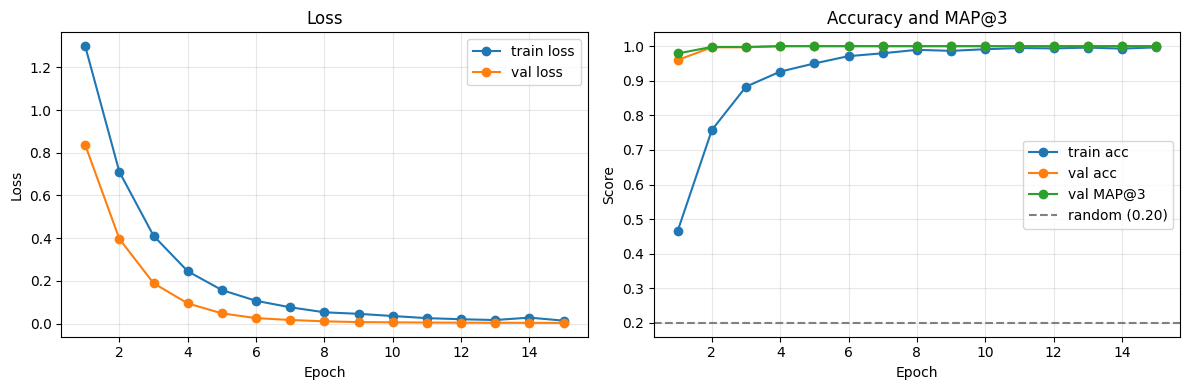

In [27]:
hist = pd.DataFrame(best_run["history"])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist["epoch"], hist["train_loss"], marker='o', label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], marker='o', label="val loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(hist["epoch"], hist["train_acc"], marker='o', label="train acc")
plt.plot(hist["epoch"], hist["val_acc"], marker='o', label="val acc")
plt.plot(hist["epoch"], hist["val_map3"], marker='o', label="val MAP@3")
plt.axhline(0.2, color='gray', linestyle='--', label="random (0.20)")
plt.title("Accuracy and MAP@3")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Compare all 3 runs on the same graph**

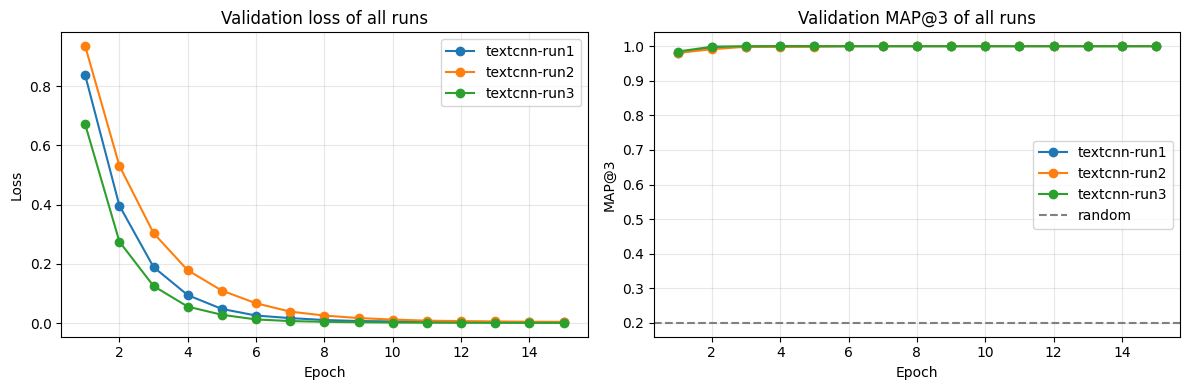

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for r in run_results:
    h = pd.DataFrame(r["history"])
    plt.plot(h["epoch"], h["val_loss"], marker='o', label=r["run_name"])
plt.title("Validation loss of all runs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for r in run_results:
    h = pd.DataFrame(r["history"])
    plt.plot(h["epoch"], h["val_map3"], marker='o', label=r["run_name"])
plt.axhline(0.2, color='gray', linestyle='--', label="random")
plt.title("Validation MAP@3 of all runs")
plt.xlabel("Epoch")
plt.ylabel("MAP@3")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Inference and submission**

In [29]:
model = MCQTextCNN(
    vocab_size=len(tokenizer.word2idx),
    embed_dim=BEST_CONFIG['embed_dim'],
    num_filters=BEST_CONFIG['num_filters'],
    kernel_sizes=BEST_CONFIG['kernel_sizes'],
    dropout=BEST_CONFIG['dropout']
)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=CONFIG['device']))
model.to(CONFIG['device'])
model.eval()

# no augmentation for the test data
test_dataset = MCQDataset(test, tokenizer, CONFIG['max_len'], is_train=False, augment=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

all_probs = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        input_ids = batch['input_ids'].to(CONFIG['device'])
        mask = batch['mask'].to(CONFIG['device'])
        logits = model(input_ids, mask)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)

all_probs = np.vstack(all_probs)

# take the top 3 options in order because the metric is MAP@3
top3 = np.argsort(-all_probs, axis=1)[:, :3]

predictions = []
for row in top3:
    predictions.append(IDX2LABEL[row[0]] + " " + IDX2LABEL[row[1]] + " " + IDX2LABEL[row[2]])

submission = pd.DataFrame({
    'ID': test['id'],
    'Prediction': predictions
})

submission.to_csv("submission.csv", index=False)
print("submission.csv is created, shape:", submission.shape)
print(submission.head())

Predicting: 100%|██████████| 16/16 [00:00<00:00, 73.52it/s]

submission.csv is created, shape: (500, 2)
   ID Prediction
0   1      A E B
1   2      B C E
2   3      B E D
3   4      E D C
4   5      C D A


**How many times each option came first in my predictions**

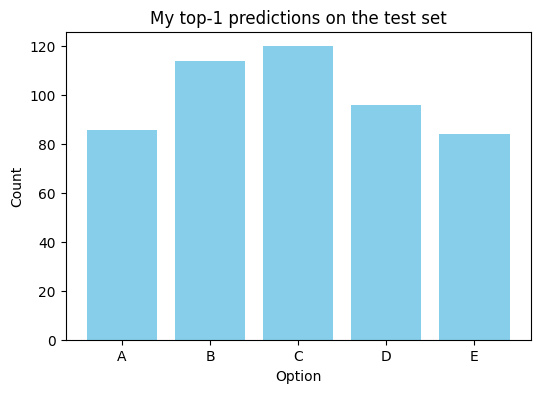

A     86
B    114
C    120
D     96
E     84
Name: count, dtype: int64

If this is very unbalanced then my model is guessing one option too often.


In [30]:
first_choice = [p.split()[0] for p in predictions]
counts = pd.Series(first_choice).value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.title("My top-1 predictions on the test set")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

print(counts)
print()
print("If this is very unbalanced then my model is guessing one option too often.")